# GNN Node Classification Pipeline — Registry-Driven

Change **one line** (`DATASET_NAME`) to switch between datasets.
Everything else — schema, categorical values, target mapping, synthetic
distributions, class names, output paths — is resolved automatically from the
`REGISTRY`.

| Variable | Default | Alternatives |
|---|---|---|
| `DATASET_NAME` | `"german_credit"` | `"adult_census"` |

## Imports & Configuration

In [1]:
%matplotlib inline
import os
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

## ► The Only Line You Need to Change

In [2]:
# ============================================================
DATASET_NAME = "german_credit"   # or "adult_census"
# ============================================================

CONFIG = {
    "hidden_dim":   64,
    "dropout":      0.5,
    "lr":           0.01,
    "weight_decay": 5e-4,
    "epochs":       200,
    "k_neighbors":  5,
}

## Dataset Registry

Each entry is a self-contained description of one dataset:

| Key | Purpose |
|---|---|
| `url` | Download source (UCI) |
| `columns` | All column names in order |
| `target_col` + `target_map` | Target extraction and 0/1 remapping |
| `class_names` | Labels for reports and plots |
| `numerical_cols` | Columns to StandardScale; rest get LabelEncoder |
| `n_synthetic` | Rows to generate if download is unavailable |
| `columns_spec` | Per-column synthetic generation spec |

In [3]:
REGISTRY: dict[str, dict] = {

    # -------------------------------------------------------------------
    "german_credit": {
        "dir": os.path.join("datasets", "german_credit"),
        "url": (
            "https://archive.ics.uci.edu/ml/machine-learning-databases"
            "/statlog/german/german.data"
        ),
        "sep": " ",
        "columns": [
            "checking_account", "duration",        "credit_history",
            "purpose",          "credit_amount",   "savings_account",
            "employment",       "installment_rate","personal_status",
            "other_debtors",    "residence_since", "property",
            "age",              "other_installments","housing",
            "existing_credits", "job",             "num_dependents",
            "telephone",        "foreign_worker",  "target",
        ],
        "target_col":     "target",
        "target_map":     {1: 0, 2: 1},
        "class_names":    ["Good Credit (0)", "Bad Credit (1)"],
        "numerical_cols": [
            "duration", "credit_amount", "installment_rate",
            "residence_since", "age", "existing_credits", "num_dependents",
        ],
        "n_synthetic": 1000,
        "columns_spec": {
            "checking_account":   {"type": "categorical",
                                   "values": ["A11","A12","A13","A14"]},
            "duration":           {"type": "int_uniform", "low": 4,   "high": 72},
            "credit_history":     {"type": "categorical",
                                   "values": ["A30","A31","A32","A33","A34"]},
            "purpose":            {"type": "categorical",
                                   "values": ["A40","A41","A42","A43","A44",
                                              "A45","A46","A47","A48","A49","A410"]},
            "credit_amount":      {"type": "int_uniform", "low": 250, "high": 18500},
            "savings_account":    {"type": "categorical",
                                   "values": ["A61","A62","A63","A64","A65"]},
            "employment":         {"type": "categorical",
                                   "values": ["A71","A72","A73","A74","A75"]},
            "installment_rate":   {"type": "int_uniform", "low": 1,   "high": 5},
            "personal_status":    {"type": "categorical",
                                   "values": ["A91","A92","A93","A94","A95"]},
            "other_debtors":      {"type": "categorical",
                                   "values": ["A101","A102","A103"]},
            "residence_since":    {"type": "int_uniform", "low": 1,   "high": 5},
            "property":           {"type": "categorical",
                                   "values": ["A121","A122","A123","A124"]},
            "age":                {"type": "int_uniform", "low": 19,  "high": 75},
            "other_installments": {"type": "categorical",
                                   "values": ["A141","A142","A143"]},
            "housing":            {"type": "categorical",
                                   "values": ["A151","A152","A153"]},
            "existing_credits":   {"type": "int_uniform", "low": 1,   "high": 5},
            "job":                {"type": "categorical",
                                   "values": ["A171","A172","A173","A174"]},
            "num_dependents":     {"type": "int_uniform", "low": 1,   "high": 3},
            "telephone":          {"type": "categorical",
                                   "values": ["A191","A192"]},
            "foreign_worker":     {"type": "categorical",
                                   "values": ["A201","A202"]},
            "target":             {"type": "categorical",
                                   "values": [1, 2],
                                   "weights": [0.70, 0.30]},
        },
    },

    # -------------------------------------------------------------------
    "adult_census": {
        "dir": os.path.join("datasets", "adult_census"),
        "url": (
            "https://archive.ics.uci.edu/ml/machine-learning-databases"
            "/adult/adult.data"
        ),
        "sep": ",",
        "columns": [
            "age", "workclass", "fnlwgt", "education", "education_num",
            "marital_status", "occupation", "relationship", "race", "sex",
            "capital_gain", "capital_loss", "hours_per_week",
            "native_country", "income",
        ],
        "target_col":  "income",
        "target_map":  {"<=50K": 0, ">50K": 1},
        "class_names": ["<=50K (0)", ">50K (1)"],
        "numerical_cols": [
            "age", "fnlwgt", "education_num",
            "capital_gain", "capital_loss", "hours_per_week",
        ],
        "n_synthetic": 48_842,
        "columns_spec": {
            "age":            {"type": "int_normal",  "mean": 38.6, "std": 13.6,
                               "min": 17, "max": 90},
            "workclass":      {"type": "categorical",
                               "values":  ["Private","Self-emp-not-inc","Self-emp-inc",
                                           "Federal-gov","Local-gov","State-gov",
                                           "Without-pay","Never-worked"],
                               "weights": [0.690,0.080,0.030,0.030,0.060,
                                           0.040,0.005,0.005]},
            "fnlwgt":         {"type": "int_uniform", "low": 13_000, "high": 1_500_000},
            "education":      {"type": "categorical",
                               "values":  ["Bachelors","Some-college","11th","HS-grad",
                                           "Prof-school","Assoc-acdm","Assoc-voc","9th",
                                           "7th-8th","12th","Masters","1st-4th","10th",
                                           "Doctorate","5th-6th","Preschool"],
                               "weights": [0.164,0.223,0.039,0.316,0.018,0.033,
                                           0.042,0.016,0.020,0.014,0.053,0.006,
                                           0.015,0.013,0.009,0.002]},
            "education_num":  {"type": "int_normal",  "mean": 10.1, "std": 2.6,
                               "min": 1, "max": 16},
            "marital_status": {"type": "categorical",
                               "values":  ["Married-civ-spouse","Divorced","Never-married",
                                           "Separated","Widowed",
                                           "Married-spouse-absent","Married-AF-spouse"],
                               "weights": [0.459,0.135,0.328,0.032,0.033,0.010,0.003]},
            "occupation":     {"type": "categorical",
                               "values":  ["Tech-support","Craft-repair","Other-service",
                                           "Sales","Exec-managerial","Prof-specialty",
                                           "Handlers-cleaners","Machine-op-inspct",
                                           "Adm-clerical","Farming-fishing",
                                           "Transport-moving","Priv-house-serv",
                                           "Protective-serv","Armed-Forces"],
                               "weights": [0.029,0.123,0.107,0.076,0.099,0.126,
                                           0.042,0.062,0.114,0.031,0.049,0.015,
                                           0.020,0.003]},
            "relationship":   {"type": "categorical",
                               "values":  ["Wife","Own-child","Husband",
                                           "Not-in-family","Other-relative","Unmarried"],
                               "weights": [0.105,0.188,0.401,0.155,0.032,0.119]},
            "race":           {"type": "categorical",
                               "values":  ["White","Asian-Pac-Islander",
                                           "Amer-Indian-Eskimo","Other","Black"],
                               "weights": [0.855,0.031,0.010,0.008,0.096]},
            "sex":            {"type": "categorical",
                               "values":  ["Male","Female"],
                               "weights": [0.669,0.331]},
            "capital_gain":   {"type": "sparse_int",  "low": 1, "high": 99_999,
                               "zero_prob": 0.917},
            "capital_loss":   {"type": "sparse_int",  "low": 1, "high": 4_356,
                               "zero_prob": 0.953},
            "hours_per_week": {"type": "int_normal",  "mean": 40.4, "std": 12.3,
                               "min": 1, "max": 99},
            "native_country": {"type": "categorical",
                               "values":  [
                                   "United-States","Cuba","Jamaica","India","Mexico",
                                   "South","Japan","Philippines","Germany","Canada",
                                   "Puerto-Rico","El-Salvador","Greece","Italy","China",
                                   "South-Korea","Iran","Poland","Columbia","Haiti",
                                   "Portugal","Taiwan","Hungary","Honduras","Ecuador",
                                   "Peru","France","Guatemala","Nicaragua","Vietnam",
                                   "Trinadad&Tobago","Laos","Thailand","Yugoslavia",
                                   "Dominican-Republic","Cambodia","Ireland","Hong",
                                   "Scotland","Outlying-US(Guam-USVI-etc)",
                                   "England","Holland-Netherlands"],
                               "weights": [0.90] + [0.10/41]*41},
            "income":         {"type": "categorical",
                               "values":  ["<=50K",">50K"],
                               "weights": [0.7592,0.2408]},
        },
    },
}

## Generic Synthetic Data Generator

In [4]:
def _make_column(spec: dict, n: int, rng: np.random.Generator) -> np.ndarray:
    t = spec["type"]
    if t == "categorical":
        w = spec.get("weights")
        if w is not None:
            w = np.array(w, dtype=float); w /= w.sum()
        return rng.choice(spec["values"], size=n, p=w)
    if t == "int_uniform":
        return rng.integers(spec["low"], spec["high"] + 1, size=n)
    if t == "int_normal":
        return np.clip(rng.normal(spec["mean"], spec["std"], n).round().astype(int),
                       spec["min"], spec["max"])
    if t == "sparse_int":
        mask = rng.random(n) < spec["zero_prob"]
        return np.where(mask, 0, rng.integers(spec["low"], spec["high"] + 1, size=n))
    raise ValueError(f"Unknown spec type: {t!r}")


def _generate_synthetic(cfg: dict, path: str) -> None:
    rng = np.random.default_rng(42)
    n   = cfg["n_synthetic"]
    data = {col: _make_column(cfg["columns_spec"][col], n, rng)
            for col in cfg["columns"]}
    pd.DataFrame(data, columns=cfg["columns"]).to_csv(
        path, sep=cfg["sep"], index=False, header=False)
    print(f"  Synthetic data written → {path}  ({n:,} rows)")

## === Setup: Dataset Acquisition ===

In [5]:
def download_data(cfg: dict) -> None:
    os.makedirs(cfg["dir"], exist_ok=True)
    raw_file = os.path.join(cfg["dir"], os.path.basename(cfg["url"]))
    csv_file = os.path.splitext(raw_file)[0] + ".csv"
    cfg["_raw_file"] = raw_file
    cfg["_csv_file"] = csv_file

    if os.path.exists(raw_file):
        print(f"  Already exists: {raw_file}")
    else:
        print(f"  Downloading from {cfg['url']} …")
        try:
            urllib.request.urlretrieve(cfg["url"], raw_file)
            print(f"  Saved → {raw_file}")
        except Exception as exc:
            print(f"  Download failed ({exc}). Using synthetic fallback …")
            _generate_synthetic(cfg, raw_file)

    df = pd.read_csv(raw_file, sep=cfg["sep"], header=None,
                     names=cfg["columns"], skipinitialspace=True, na_values="?")
    df.dropna(inplace=True)
    df.to_csv(csv_file, index=False)
    print(f"  CSV saved → {csv_file}")

    tgt  = cfg["target_col"]
    dist = df[tgt].value_counts().to_dict()
    print(f"  Samples  : {len(df):,} | Features: {len(cfg['columns'])-1}")
    print(f"  Target   : {tgt} distribution → {dist}")


print("=== Setup: Dataset Acquisition ===")
cfg = REGISTRY[DATASET_NAME]
download_data(cfg)

=== Setup: Dataset Acquisition ===
  Already exists: datasets/german_credit/german.data
  CSV saved → datasets/german_credit/german.csv
  Samples  : 1,000 | Features: 20
  Target   : target distribution → {1: 683, 2: 317}


## Preprocessing

In [6]:
def preprocess(cfg: dict) -> tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(cfg["_raw_file"], sep=cfg["sep"], header=None,
                     names=cfg["columns"], skipinitialspace=True, na_values="?")
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

    tgt    = cfg["target_col"]
    df[tgt] = df[tgt].map(cfg["target_map"])
    df.dropna(subset=[tgt], inplace=True)
    y = df.pop(tgt).values.astype(np.int64)

    cat_cols = [c for c in df.columns if c not in cfg["numerical_cols"]]
    for col in cat_cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

    df[cfg["numerical_cols"]] = StandardScaler().fit_transform(df[cfg["numerical_cols"]])
    X = df.values.astype(np.float32)

    unique, counts = np.unique(y, return_counts=True)
    print(f"  Encoded  : {X.shape[0]:,} samples × {X.shape[1]} features")
    print(f"  Labels   : {dict(zip(cfg['class_names'], counts))}")
    return X, y


torch.manual_seed(42)
np.random.seed(42)
X, y = preprocess(cfg)

  Encoded  : 1,000 samples × 20 features
  Labels   : {'Good Credit (0)': np.int64(683), 'Bad Credit (1)': np.int64(317)}


## Build KNN Graph + Node Masks (60 / 20 / 20)

In [7]:
def build_graph(X: np.ndarray, y: np.ndarray) -> Data:
    k = CONFIG["k_neighbors"]
    print(f"  Building KNN graph  k={k} …")
    A  = kneighbors_graph(X, n_neighbors=k, mode="connectivity", include_self=False)
    cx = A.tocoo()
    edge_index = torch.tensor(np.vstack([cx.row, cx.col]), dtype=torch.long)

    data = Data(x=torch.tensor(X, dtype=torch.float),
                edge_index=edge_index,
                y=torch.tensor(y, dtype=torch.long))

    n     = data.num_nodes
    perm  = torch.randperm(n, generator=torch.Generator().manual_seed(42))
    n_tr  = int(0.60 * n)
    n_val = int(0.20 * n)

    data.train_mask = torch.zeros(n, dtype=torch.bool)
    data.val_mask   = torch.zeros(n, dtype=torch.bool)
    data.test_mask  = torch.zeros(n, dtype=torch.bool)
    data.train_mask[perm[:n_tr]]             = True
    data.val_mask  [perm[n_tr:n_tr + n_val]] = True
    data.test_mask [perm[n_tr + n_val:]]     = True

    print(f"  Nodes: {n:,} | Edges: {edge_index.size(1):,}")
    print(f"  Split → Train: {data.train_mask.sum().item()} | "
          f"Val: {data.val_mask.sum().item()} | "
          f"Test: {data.test_mask.sum().item()}")
    return data


data = build_graph(X, y)

  Building KNN graph  k=5 …
  Nodes: 1,000 | Edges: 5,000
  Split → Train: 600 | Val: 200 | Test: 200


## GCN Model Definition

In [8]:
class GCN(torch.nn.Module):
    """Two-layer Graph Convolutional Network."""
    def __init__(self, in_channels, hidden_dim, out_channels, dropout):
        super().__init__()
        self.conv1   = GCNConv(in_channels, hidden_dim)
        self.conv2   = GCNConv(hidden_dim, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)


def build_model(in_channels, num_classes=2):
    return GCN(in_channels=in_channels,
               hidden_dim=CONFIG["hidden_dim"],
               out_channels=num_classes,
               dropout=CONFIG["dropout"])

print(build_model(data.num_node_features))

GCN(
  (conv1): GCNConv(20, 64)
  (conv2): GCNConv(64, 2)
)


## === Phase 1: Training ===

=== Phase 1: Training ===
  Device: cpu
  Epoch   1/200 — Loss: 1.1575
  Epoch  10/200 — Loss: 0.7702
  Epoch  20/200 — Loss: 0.6454


  Epoch  30/200 — Loss: 0.6228


  Epoch  40/200 — Loss: 0.6033
  Epoch  50/200 — Loss: 0.5902


  Epoch  60/200 — Loss: 0.5911
  Epoch  70/200 — Loss: 0.5738
  Epoch  80/200 — Loss: 0.5513


  Epoch  90/200 — Loss: 0.5594


  Epoch 100/200 — Loss: 0.5536
  Epoch 110/200 — Loss: 0.5479


  Epoch 120/200 — Loss: 0.5420
  Epoch 130/200 — Loss: 0.5537
  Epoch 140/200 — Loss: 0.5291


  Epoch 150/200 — Loss: 0.5398


  Epoch 160/200 — Loss: 0.5169
  Epoch 170/200 — Loss: 0.5296


  Epoch 180/200 — Loss: 0.5244
  Epoch 190/200 — Loss: 0.5149
  Epoch 200/200 — Loss: 0.4949
  Model saved → datasets/german_credit/trained_model.pt


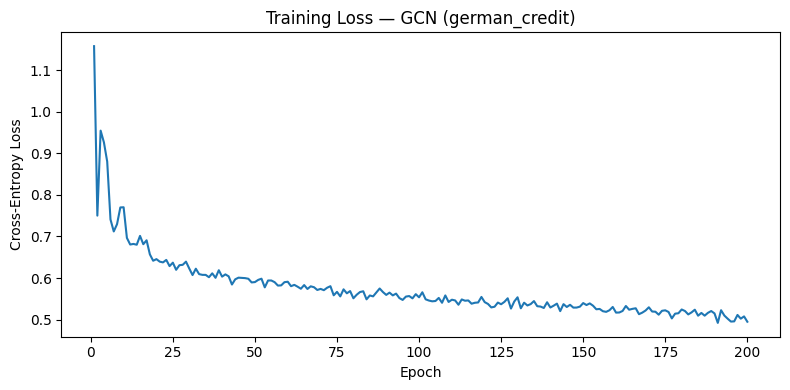

  Loss curve → datasets/german_credit/training_loss_curve.png


In [9]:
def train(data: Data, cfg: dict) -> None:
    model_file      = os.path.join(cfg["dir"], "trained_model.pt")
    loss_curve_file = os.path.join(cfg["dir"], "training_loss_curve.png")
    cfg["_model_file"] = model_file

    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"  Device: {device}")
    model     = build_model(in_channels=data.num_node_features).to(device)
    data_d    = data.to(device)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
    criterion = torch.nn.CrossEntropyLoss()

    losses = []
    model.train()
    for epoch in range(1, CONFIG["epochs"] + 1):
        optimizer.zero_grad()
        loss = criterion(model(data_d.x, data_d.edge_index)[data_d.train_mask],
                         data_d.y[data_d.train_mask])
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3}/{CONFIG['epochs']} — Loss: {loss.item():.4f}")

    torch.save(model.state_dict(), model_file)
    print(f"  Model saved → {model_file}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, CONFIG["epochs"] + 1), losses, linewidth=1.5)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
    ax.set_title(f"Training Loss — GCN ({DATASET_NAME})")
    plt.tight_layout()
    plt.savefig(loss_curve_file, dpi=150)
    plt.show()
    print(f"  Loss curve → {loss_curve_file}")


print("=== Phase 1: Training ===")
train(data, cfg)

## === Phase 2: Validation ===

=== Phase 2: Validation ===
  Loaded weights from datasets/german_credit/trained_model.pt

  Classification Report — german_credit (Validation):
                 precision    recall  f1-score   support

Good Credit (0)     0.6946    0.8345    0.7582       139
 Bad Credit (1)     0.3030    0.1639    0.2128        61

       accuracy                         0.6300       200
      macro avg     0.4988    0.4992    0.4855       200
   weighted avg     0.5752    0.6300    0.5918       200



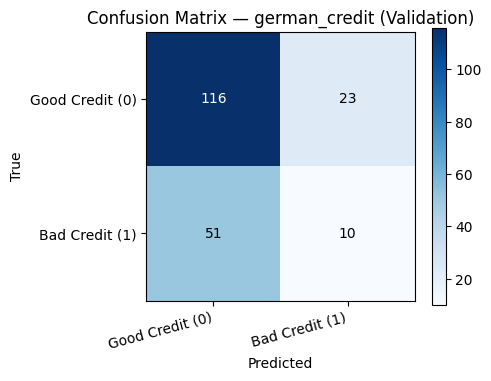

  Confusion matrix → datasets/german_credit/validation_confusion_matrix.png


In [10]:
def validate(data: Data, cfg: dict) -> None:
    model_file     = cfg["_model_file"]
    confusion_file = os.path.join(cfg["dir"], "validation_confusion_matrix.png")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = build_model(in_channels=data.num_node_features).to(device)
    model.load_state_dict(torch.load(model_file, map_location=device))
    print(f"  Loaded weights from {model_file}")

    data_d = data.to(device)
    model.eval()
    with torch.no_grad():
        preds = model(data_d.x, data_d.edge_index).argmax(dim=1)

    val_preds  = preds[data_d.val_mask].cpu().numpy()
    val_labels = data_d.y[data_d.val_mask].cpu().numpy()

    print(f"\n  Classification Report — {DATASET_NAME} (Validation):")
    print(classification_report(val_labels, val_preds,
                                target_names=cfg["class_names"], digits=4))

    cm    = confusion_matrix(val_labels, val_preds)
    names = cfg["class_names"]
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    fig.colorbar(im, ax=ax)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=15, ha="right")
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — {DATASET_NAME} (Validation)")
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.savefig(confusion_file, dpi=150)
    plt.show()
    print(f"  Confusion matrix → {confusion_file}")


print("=== Phase 2: Validation ===")
validate(data, cfg)